# Hull & White One Factor Model
------------------
> **Idriss Afra**

This project aims to implement the Hull & White One Factor model and apply it to price Bermudan Swaptions.

## Model Dynamics

The Hull-White One Factor model is a mono-curve short rate model. It assumes the following SDE :

$$dX_t = λ \left(\frac{Φ(t)}{λ} - X_t\right) dt + σ(t) dW_t$$

Where :    

- $X_t = r(t) - f(0, t) \text{}$, with $r_t$ being the short rate and $f(0, t)$ being the instantaneous forward rate $\left(X_0 = 0\right)$.

- $λ$ is the speed at which the short rate reverts to its long-term mean, i.e. the mean-reversion.
- $σ(t)$ is the short rate instantaneous volatility.
- $Φ(t) = ∫^{t}_{0} σ(s)^{2} e^{-2λ(t-s)} ds$ is seen as the short rate's total variance.

---
## Zero-Coupon Bond Hull-White Price

In the Hull-White One Factor model, the stochastic price of a zero-coupon bond at time $t$ with maturity $T$ is given by :     

$$
B(t, T) = E_t\left( e^{-∫_t^Tr_udu} \right) = \frac{B(0, T)}{B(0, t)} × e^{\left( -\frac{1}{2} × β(t, T)^{2} × Φ(t) - β(t, T) × X_t \right)}
$$

Where :    

$$
β(t, T) = \frac{1 - e^{-λ (T-t)}}{λ}
$$

---
## European Swaption Hull-White Price

In the Hull-White One Factor model, a European swaption can be valued by replicating it with a portfolio of bond options, using the approach known as Jamshidian’s decomposition. The present value of a payer or receiver swaption is then given by:

$$
PV_{HW}^{Pay/Rec} = B(0, T_0) × ∑_{i = 1}^{n}c_i × BS^{Put/Call}\left( T_{e}, K_i, \frac{B(0, T_i)}{B(0, T_0)}, σ_i \right)
$$

Where:
- $T_e$ is the swaption expiry, $T_0$ is the start date of the underlying swap, and $(T_i)_{1 ≤ i ≤ n}$ are the fixed leg payment dates of the underlying swap

- $c_i = \delta_i \times K$ and $c_n = 1 + \delta_n \times K$, with $(\delta_i)_{i ≤ n}$ being the fixed leg day count fractions and $K$ being the swaption strike rate

- $BS$ : denotes Black’s formula applied to the forward bond ratio

- $(K_i)_{i ≤ n}$ are the bond-option strikes induced by the Jamshidian root: $\left(∃! x_0 ∈ ℜ\right): K_i := \frac{B(T_{e}, T_i)(x_0)}{B(T_{e}, T_0)(x_0)} $, and: $∑_{i = 1}^{n}c_iK_i = 1$

- $ σ_{i} = \sqrt{ \frac{Φ(T_e) × \left(e^{-λ(T_0-T_e)} - e^{-λ(T_i-T_e)}\right)^{2}}{λ^{2} T_e} }$ : The overall log-normal volatility of $\left( \frac{B(t, T_i)}{B(t, T_0)} \right)_t$ up to the expiry $T_e$

A detailed proof of derivation is available in the following document : [Hull-White One Factor Model Documentation](https://github.com/Idriss-Afra/Hull-White-One-Factor-Model/blob/main/Hull-White%20One%20Factor%20Model%20Documentation.pdf).

---
## Hull-White Model Calibration


To use the Hull-White one-factor model for pricing, two key parameters must be calibrated :

- $\lambda$: The mean-reversion rate.
- $\sigma(t)$: The time-dependent volatility of the short rate.

Previously, the mean-reversion parameter was calibrated using Bermudan swaption market quotes. But as liquidity in that market declined, it became standard practice to fix $\lambda$ based on the rate market conditions. On the other hand, the volatility function $\sigma(t)$ is typically modeled as piecewise constant across the expiry dates of the instruments used in calibration (such as swaptions or caps/floors) to ensure a stable and simple process. In this project, the calibration basket consists of European swaptions.

### The Calibration Algorithm :     

#### The short rate total variance calibration :
- Set the initial total variance : $Φ(0) = 0$
- For each expiry $T_e$ in the calibration basket, solve $Φ(T_e)$ such that :

$$
PV_{HW}(Φ(T_e)) = Market  Price
$$

#### The short rate volatility stripping :
- Set a minimum volatility level : $σ_{min} = 0.0005$ (i.e., $5$ basis points).

For each expiry $T_i$ in the calibration basket : 
- If : $Φ(T_{i+1}) > Φ(T_i)×e^{-2λ(T_{i+1}-T_i)}$, then the short rate volatility over $[T_i, T_{i+1}[$ is stripped as :

$$σ_{i} = \sqrt{2λ×\frac{Φ(T_{i+1}) - Φ(T_i)×e^{-2λ(T_{i+1}-T_i)}}{1 - e^{-2λ(T_{i+1}-T_{i})}}}$$
- Else, we floor the volatility : $σ_{i} = σ_{min}$, and then update the total variance accordingly :
$$
Φ(T_{i+1}) = Φ(T_i) × e^{-2λ(T_{i+1}-T_i)} + \frac{σ_{min}^{2}}{2λ}\left(1 - e^{-2λ(T_{i+1}-T_{i})}\right)
$$


---
## Model Implementation

We first define a zero-coupon curve class to construct discounting curves :

In [9]:
import numpy as np
from scipy.interpolate import PchipInterpolator

class ZeroCouponRateCurve:
    """
    Zero-Coupon Rate Curve class.
    """
    def __init__(self, zc_maturities, zc_rates):
        """
        Init method : Takes the IR market tenors and the bootstrapped ZC rates.
        """
        # Sanity checks
        if (not isinstance(zc_maturities, (list, np.ndarray))) or (not isinstance(zc_rates, (list, np.ndarray))):
            raise TypeError(f"ZeroCouponRateCurve : zc_maturities and zc_rates must be lists or arrays !")
        if (len(zc_maturities) != len(zc_rates)):
            raise ValueError(f"ZeroCouponRateCurve : zc_maturities and zc_rates must have the same length !")
        # Store data
        self.zc_maturities = zc_maturities
        self.zc_rates = zc_rates
        self._t0 = zc_maturities[0]
        self._t1 = zc_maturities[-1]
        self._r0 = zc_rates[0]
        self._r1 = zc_rates[-1]
        # Interpolator only valid inside [_t0, _t1]; flat extrpolation outside
        self.zc_rate_interp = PchipInterpolator(zc_maturities, zc_rates, extrapolate=False)

    def zc_rates_interp(self, T):
        """
        Interpolated ZC rate for maturity T.
        T may be a scalar or an array-like.
        """
        T = np.asarray(T)
        r_interp = np.empty_like(T)
        # Below t0, use r0
        r_interp[T < self._t0] = self._r0
        # Above t1, use r1
        r_interp[T > self._t1] = self._r1
        # Between t0 and t1, use PCHIP interpolation
        mask = (T >= self._t0) & (T <= self._t1)
        r_interp[mask] = self.zc_rate_interp(T[mask])
        return r_interp

    def df(self, T):
        """
        Zero-Coupon Discount Factors.
        T may be a scalar or an array-like.
        """
        return np.exp(-self.zc_rates_interp(T)*T)

then, we implement the swaption instrument class :

In [10]:
from scipy.stats import norm

class EuropeanSwaption:
    """
    European Swaption class under the Normal (Bachelier) model.
    """
    def __init__(self, payer_receiver, expiry, tenor, strike, fixed_frequency=1., start_date_lag=2., notional=10000.):
        """
        Init method.
        """
        # Sanity checks
        if (payer_receiver.upper() not in ['PAYER', 'RECEIVER']):
            raise ValueError(f"EuropeanSwaption : payer_receiver must be 'PAYER' or 'RECEIVER' !")
        if (expiry <= 0. or tenor <= 0.):
            raise ValueError(f"EuropeanSwaption : expiry and tenor must be positive !")
        # Store data
        self.payer_receiver = payer_receiver.upper()
        self.expiry = expiry
        self.strike = strike
        self.notional = notional
        self.start_time = expiry + start_date_lag / 365.
        # Fixed leg payment dates : Annually
        self.pay_times = np.arange(self.start_time + fixed_frequency, expiry + tenor + 1, fixed_frequency)
        self.year_fractions = np.array([fixed_frequency] * len(self.pay_times))
        self.is_market_data_set = False

    def is_payer(self):
        return (self.payer_receiver == "PAYER")

    def set_market_data(self, df, normal_vol):
        """
        Stores DFs values to save computation time.
        """
        # Sanity checks
        if not callable(df):
            raise TypeError(f"set_market_data : df must be a callable function !")
        if normal_vol <= 0:
            raise ValueError(f"set_market_data : normal_vol must be positive !")
        # Store data
        self.df_exp_time = df(self.expiry)
        self.df_start_time = df(self.start_time)
        self.df_pay_times = df(self.pay_times)
        self.normal_vol = normal_vol
        self.is_market_data_set = True

    def level(self) :
        """
        The level (annuity) function : Sum of DCF(T(i)) * B(0, T(i)) where T(i) are the fixed leg pay dates.
        """
        if not self.is_market_data_set:
            raise ValueError(f"level : Market data not set ! Call set_market_data() first !")
        return np.sum(self.df_pay_times * self.year_fractions)

    def forward(self):
        """
        The forward swap rate.
        Mono-curve framework : DFs are the same for discounting and forwarding.
        """
        if not self.is_market_data_set:
            raise ValueError(f"forward : Market data not set ! Call set_market_data() first !")
        return (self.df_start_time - self.df_pay_times[-1]) / self.level()

    def pv_underlying(self):
        """
        PV of the underlying swap (No optionality).
        Mono-curve framework : DFs are the same for discounting and forwarding.
        """
        if not self.is_market_data_set:
            raise ValueError(f"pv_underlying : Market data not set ! Call set_market_data() first !")
        flavor = 1. if self.is_payer() else -1.
        return flavor * self.notional * self.level() * (self.forward() - self.strike)

    def market_price(self):
        """
        Swaption price under the Normal (Bachelier) model.
        Mono-curve framework : DFs are the same for discounting and forwarding.
        """
        if not self.is_market_data_set:
            raise ValueError(f"market_price : Market data not set ! Call set_market_data() first !")
        flavor = 1 if self.is_payer() else -1
        lvl = self.level()
        fwd = self.forward()
        sqrt_V2T = self.normal_vol * np.sqrt(self.expiry)
        if (sqrt_V2T == 0) : return self.notional * lvl * max(flavor * (fwd - self.strike), 0.)
        d = (fwd - self.strike) / sqrt_V2T
        return self.notional * lvl * sqrt_V2T * (flavor * d * norm.cdf(flavor * d) + norm.pdf(d))


Finally, we develop the Hull-White One Factor model :

In [11]:
from scipy import optimize
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

class HullWhiteOneFactorModel:
    """
    Hull & White 1F model, with a calibration based on European Swaptions.
    """
    def __init__(self, mean_reversion=0.015, t=None, sigma_t=None):
        """
        Init method :
        - mean_reversion : Mean reversion parameter of the HW-1F model (scalar, default = 0.02)
        - t : Maturities of the calibration instruments (array-like)
        - sigma_t : Instantaneous short-rate volatility, specified as piecewise constant over t (array-like)
        """
        # Sanity checks
        if (t is None) != (sigma_t is None):
            raise ValueError("HullWhiteOneFactorModel : t and sigma_t must be provided together !")
        if t is not None and len(t) != len(sigma_t):
            raise ValueError("HullWhiteOneFactorModel : t and sigma_t must have the same length !")
        if abs(mean_reversion) < 1e-8:
            raise ValueError("HullWhiteOneFactorModel : mean_reversion must be non-zero !")
        # Store data
        self.mean_reversion = mean_reversion
        self.t = t
        self.sigma_t = sigma_t

    def price_from_phi(self, swopt, phi, max_iter=250, tol=1e-8):
        """
        HW-1F swaption price using the input total variance phi, based on the Jamshidian's decomposition.
        Reference: https://github.com/Idriss-Afra/Hull-White-One-Factor-Model/blob/main/Hull-White%20One%20Factor%20Model%20Documentation.pdf
        """
        # Sanity checks
        if not isinstance(swopt, EuropeanSwaption):
            raise TypeError(f"price_from_phi : swopt must be an instance of EuropeanSwaption !")
        if not swopt.is_market_data_set:
            raise ValueError(f"price_from_phi : swopt must have market data set !")
        if phi < 0.:
            raise ValueError(f"price_from_phi : phi must be positive !")
        # Store data
        Tf  = swopt.expiry
        T0  = swopt.start_time
        DF0 = swopt.df_start_time
        DFs = swopt.df_pay_times
        deltas = swopt.year_fractions
        # Bond options coefficients
        coefs = swopt.strike * deltas
        coefs[-1] += 1
        # Fwd Zero-Coupon Bond prices
        fwd_DFs = DFs / DF0
        # Beta functions computations
        beta0 = (1 - np.exp(-self.mean_reversion * (T0 - Tf))) / self.mean_reversion
        betas = (1 - np.exp(-self.mean_reversion * (swopt.pay_times - Tf))) / self.mean_reversion
        betas_minus_beta0 = betas - beta0
        betas2_minus_beta02 = betas**2 - beta0**2
        # Newton-Raphson algo functions to find the exercise frontier
        def f(x):
            return np.sum(coefs * fwd_DFs * np.exp(-0.5 * betas2_minus_beta02 * phi - betas_minus_beta0 * x)) - 1
        def f_deriv(x):
            return np.sum(- coefs * fwd_DFs * betas_minus_beta0 * np.exp(-0.5 * betas2_minus_beta02 * phi - betas_minus_beta0 * x))
        # Payer swap pv
        payer_swap_pv = swopt.notional * (DF0 - DFs[-1] - swopt.strike * np.sum(deltas * DFs))
        # /!\ All coefficients are negative (Large negative strike < -1/delta)
        if np.all(coefs < 0.):
            # Payer payoff is always exercised while the receiver is worthless
            return payer_swap_pv if swopt.is_payer() else 0.
        # /!\ Mixed-sign coefficients can break Jamshidian's single exercise frontier assumption (-1/delta < strike < 0)
        if np.any(coefs < 0.) and np.any(coefs > 0.):
            x_max = 8. * np.sqrt(phi)
            x_min = -x_max
            x_grid = np.linspace(x_min, x_max, 201)
            f_grid = np.array([f(x) for x in x_grid])
            s = np.sign(np.where(np.abs(f_grid) < 1e-12, 0., f_grid)) # Count sign changes
            n_changes = np.sum((s[1:] != 0.) & (s[:-1] != 0.) & (s[1:] * s[:-1] < 0.)) # Exclude exact zeros
            n_zeros = np.sum((s == 0.) & np.insert(s[:-1] != 0., 0, True))
            if n_changes == 0 and n_zeros == 0:
                # No exercise frontier (no root)
                print("[price_from_phi] Warning: The swaption has no exercise frontier and is equal to its intrinsic value.")
                if np.all(f_grid < 0.):
                    # Payer payoff = (-f)^+ -> always exercised
                    # Receiver payoff = (f)^+ -> worthless
                    return payer_swap_pv if swopt.is_payer() else 0.
                else:
                    # payer payoff = (-f)^+ -> worthless
                    # receiver payoff = ( f)^+ -> always exercised
                    return 0. if swopt.is_payer() else -payer_swap_pv
            if n_changes + n_zeros != 1:
                # More than one exercise frontier: Jamshidian's decomposition is not applicable
                raise RuntimeError(f"Error : Jamshidian's decomposition is not applicable (detected {n_changes + n_zeros} root candidate(s)).")
        # The exponential Taylor expansion formula (up to the 1st order) to find the initial guess
        guess_x = (-1 + np.sum(coefs * fwd_DFs * (1 - 0.5 * betas2_minus_beta02 * phi))) / np.sum(coefs * fwd_DFs * betas_minus_beta0)
        # The exercise frontier
        try:
            x0, info = optimize.newton(f, guess_x, fprime=f_deriv, maxiter=max_iter, tol=tol, full_output=True)
            if not info.converged:
                print(f"[price_from_phi] Warning: Newton-Raphson did not converge. Exercise frontier and final price may be inaccurate.")
        except RuntimeError as e:
            raise RuntimeError(f"[price_from_phi] Error: Newton-Raphson failed to find the exercise frontier.") from e
        # Bond options strikes
        strikes = fwd_DFs * np.exp(-0.5 * betas2_minus_beta02 * phi - betas_minus_beta0 * x0)
        # Bond options volatilities
        vols = np.sqrt(phi / Tf) * (np.exp(-self.mean_reversion * (T0 - Tf)) - np.exp(-self.mean_reversion * (swopt.pay_times - Tf))) / self.mean_reversion
        # Bond options flavors : Payer Swaption => Put Bond options || Receiver Swaption => Call Bond options
        flavor = -1. if swopt.is_payer() else 1.
        # Black formula of the Bond options
        d1 = (np.log(fwd_DFs / strikes) + 0.5 * vols**2 * Tf) / (vols * np.sqrt(Tf))
        d2 = d1 - vols * np.sqrt(Tf)
        bs_fwd = flavor * fwd_DFs * norm.cdf(flavor * d1) - flavor * strikes * norm.cdf(flavor* d2)
        # Hull-White swaption price
        return swopt.notional * DF0 * np.sum(coefs * bs_fwd)

    def calibrate_phi(self, instr, max_iter=250, tol=1e-8):
        """
        NR Solver of the total variance Phi given a calibration instrument "instr".
        """
        # Sanity checks
        if not isinstance(instr, EuropeanSwaption):
            raise TypeError(f"calibrate_phi : instr must be an instance of EuropeanSwaption !")
        if not instr.is_market_data_set:
            raise ValueError(f"calibrate_phi : instr must have market data set !")
        if instr.strike <= 0:
            tenor = instr.pay_times[-1] - instr.start_time
            print(f"[calibrate_phi] Warning: non-positive strike (K={instr.strike:g}) "
                  f"for instrument (expiry={instr.expiry:g}, tenor={tenor:g}). "
                   "Calibration may be unstable or fail.")
        # Relevant functions for the Newton-Raphson algorithm
        market_price = instr.market_price()
        def f(phi):
            """
            HW-1F Price - Market (Normal) Price.
            """
            return self.price_from_phi(instr, phi) - market_price
        def f_deriv(phi, eps=1e-6):
            """
            Derivative function of f : Central Finite Difference method.
            """
            if phi <= eps: return (f(phi+eps) - f(phi)) / eps
            return (f(phi+eps) - f(phi-eps)) / (2.*eps)
        # Initial Guess : total normal variance
        guess_phi = instr.normal_vol**2 * instr.expiry
        # Phi solver
        try:
            phi_calibrated, info = optimize.newton(f, guess_phi, fprime=f_deriv, maxiter=max_iter, tol=tol, full_output=True)
            if not info.converged:
                print(f"[calibrate_phi] Warning: Newton-Raphson did not converge. Phi result may be inaccurate.")
            return phi_calibrated
        except RuntimeError as e:
            print(f"[calibrate_phi] Error: Newton-Raphson failed to find the total variance phi because {e}. Returning NaN.")
            return np.nan

    def calibrate_sigma(self, calib_set, sigma_min=0.0005):
        """
        Calibration of sigma(t) term structure based on a set of instruments.
        """
        # 1st step : Calibrate Phi on different calib maturities
        phi = []
        for instr in calib_set:
            phi.append(self.calibrate_phi(instr))
        # 2nd step : Back out the piecewise constant sigma(t) from the calibrated Phi values
        t = np.empty(len(calib_set)+1)
        sigma_t = np.empty(len(calib_set)+1)
        # Init values : Phi(t=0) = 0
        t[0] = 0
        last_phi = 0
        for i in range(len(calib_set)):
            t[i+1] = calib_set[i].expiry
            tenor = calib_set[i].pay_times[-1] - calib_set[i].start_time
            exp = np.exp(-2 * self.mean_reversion * (t[i+1] - t[i]))
            last_term = exp * last_phi
            if np.isnan(phi[i]):
                # Calibration failure : Fallback to sigma_min and update the variance Phi accordingly
                sigma_t[i] = sigma_min
                phi[i] = last_term + sigma_min**2 * (1 - exp) / (2 * self.mean_reversion)
                print("[calibrate_sigma] Warning: volatility squeeze at step {}. Instrument [expiry = {} / tenor = {}] will be mispriced".format(i+1, t[i+1], tenor))
            elif (phi[i] < last_term):
                # Fallback to sigma_min and update the variance Phi accordingly
                sigma_t[i] = sigma_min
                phi[i] = last_term + sigma_min**2 * (1 - exp) / (2 * self.mean_reversion)
                print("[calibrate_sigma] Warning: volatility squeeze at step {}. Instrument [expiry = {} / tenor = {}] will be mispriced".format(i+1, t[i+1], tenor))
            else :
                sigma_t[i] = np.sqrt(2 * self.mean_reversion * (phi[i] - last_term) / (1 - exp) )
                if (sigma_t[i] < sigma_min) :
                    sigma_t[i] = sigma_min
                    phi[i] = last_term + sigma_min**2 * (1 - exp) / (2 * self.mean_reversion)
                    print("[calibrate_sigma] Warning: volatility squeeze at step {}. Instrument [expiry = {} / tenor = {}] will be mispriced".format(i+1, t[i+1], tenor))
            last_phi = phi[i]
        # Flat extrapolation after the last maturity => Same size for t & sigma_t
        sigma_t[-1] = sigma_t[-2]
        # End of the calibration process : Store the HW short rate vol
        self.t = t
        self.sigma_t = sigma_t

    def get_phi(self, t) :
        """
        Computes the total variance Phi up to calib maturities t.
        t may be a scalar or an array-like.
        """
        t = np.asarray(t, dtype=float)
        # Sanity checks
        if self.t is None or self.sigma_t is None:
            raise ValueError("get_phi : model volatility term structure is not calibrated/set !")
        if np.any(t < 0.):
            raise ValueError("get_phi : t must be non-negative !")
        # Add the array t to the maturities of the calibration instruments self.t => new_t
        new_t = np.append(self.t, t)
        new_t = np.delete(new_t, np.where(new_t > np.max(t)))
        new_t = np.unique(new_t)
        new_t = np.sort(new_t)
        # Phi values on new_t : self.sigma_t is piecewise constant on self.t
        sigma = interp1d(self.t, self.sigma_t, kind="previous", fill_value="extrapolate")
        sigma_new_t = sigma(new_t)
        phi_new_t = np.empty(len(new_t))
        phi_new_t[0] = 0
        exp_lambda_t = np.exp(2 * self.mean_reversion * new_t)
        for i in range(len(new_t) - 1) :
            phi_new_t[i+1] = (phi_new_t[i] * exp_lambda_t[i] + sigma_new_t[i]**2 * (exp_lambda_t[i+1] - exp_lambda_t[i]) / (2 * self.mean_reversion)) / exp_lambda_t[i+1]
        # Phi values on t
        phi_new_t = interp1d(new_t, phi_new_t, kind="previous", fill_value="extrapolate")
        return phi_new_t(t)

    def price(self, swopt):
        """
        HW-1F price of the swaption instrument "swopt".
        """
        # Get phi at the swopt's expiry
        t = np.array([swopt.expiry])
        phi = self.get_phi(t)[0]
        # HW1F price using phi
        return self.price_from_phi(swopt, phi)

    def print(self):
        """
        Prints the calibration details.
        """
        print("------------------------------------")
        print("HW-1F MODEL | Mean reversion = {:.2f}%\nVol sigma(t) (bp) = ".format(self.mean_reversion*100.))
        for i in range(len(self.t)-1) :
            print("Short rate vol on [" + str(self.t[i]) + ", " + str(self.t[i+1]) + "[ : " + str(round(self.sigma_t[i] * 10000, 2)))
        print("Then, flat extrapolation...")
        plt.title("HW Short Rate Volatility")
        plt.ylabel("HW Vol (bp)")
        plt.xlabel("Expiry")
        x_axis = np.linspace(0, self.t[-1] + 0.1, 501)
        sigma = interp1d(self.t, 10000 * self.sigma_t, kind="previous", fill_value="extrapolate")
        plt.plot(x_axis, sigma(x_axis))
        plt.show()


---
## Hull-White PDE Pricing Method

Using Itô’s lemma under the risk-neutral measure, we derive the following partial differential equation (PDE) :

$$
\frac{\partial v(t, x)}{\partial t} + \mu(t, x)\frac{\partial v(t, x)}{\partial x} + \frac{1}{2}\sigma(t)^2 \frac{\partial^2 v(t, x)}{\partial x^2} - r(t, x)v(t, x) = 0
$$

Where the drift is : $ \mu(t, x) = Φ(t) - λx $

### The Finite Difference Method

To solve the PDE numerically, we use the finite difference approximations for derivatives :

- $1^{st}$ order derivative in space : $ D_1 v(t, x)= \frac{v(t, x^+)-v(t, x^-)}{x^+-x^-}\approx \frac{\partial v}{\partial x}(t, x) $

- $2^{nd}$ order derivative in space :

$$
D_2 v(t, x)=
\frac{\frac{v(t, x^+)-v(t, x)}{x^+-x}-\frac{v(t, x)-v(t, x^-)}{x-x^-}}{\frac{x^+ + x}{2}-\frac{x + x^-}{2}}=
2\left\{\frac{v(t, x^+)-v(t, x)}{(x^+-x^-)(x^+-x)}-\frac{v(t, x)-v(t, x^-)}{(x^+-x^-)(x-x^-)}\right\}\approx \frac{\partial^2 v}{\partial x^2}(t,x)
$$

We then approximate the spatial part of the PDE as :   

$$
\mu(t, x)\frac{\partial v(t, x)}{\partial x} + \frac{1}{2}\sigma(t)^2 \frac{\partial^2 v(t, x)}{\partial x^2} - r(t, x)v(t, x) \approx \frac{1}{t^+-t}\left[\bar\mu(t, x)D_1v(t,x)+\frac{1}{2}\sigma(t)^2(t^+-t)D_2v(t,x)-\bar r(t, x)v(t,x)\right] =\frac{1}{t^+-t}Av(t,x)
$$

Where :$ \bar\mu(t, x) = \int_t^{t^+}\mu(s, x)ds$ , and : $\bar r(t, x)=\int_t^{t^+}r(s, x)ds
$

On the other hand, we choose the following approximation in time : $\frac{\partial v(t, x)}{\partial t} = \frac{v(t^+, x) - v(t, x)}{t^+-t}$

Finally : $ \frac{v(t^+, x) - v(t, x)}{t^+-t} + \frac{1}{t^+-t}Av(t, x) = 0 $

And therefore : $ v(t^+, x) - v(t, x) + Av(t, x) = 0 $

We use the Crank-Nicolson scheme, which averages terms at time $t$ and $t^+$ :

$$
v(t^+,x) - v(t,x) +\theta Av(t,x) + (1-\theta) Av(t^+,x)= 0\;, \quad \theta=0.5
$$

By keeping the $v(t, x)$ terms in the left and moving the $v(t^+, x)$ terms to the right, we obtain the below equation :        

$$
p_u^l v(t,x^+) + p_c^l v(t,x) + p_d^l v(t,x^-) = p_u^r v(t^+,x^+) + p_c^r v(t^+,x) + p_d^r v(t^+,x^-)
$$

Where :
$$
\begin{split}
p_u^r &= (1-\theta) \alpha_u\\
p_d^r &= (1-\theta) \alpha_d\\
p_c^r &= (1-\theta)\alpha_c + 1 - (1-\theta)\bar r(t, x)\\
p_u^l &= -\theta \alpha_u\\
p_d^l &= -\theta \alpha_d\\
p_c^l &= - \theta\alpha_c + 1 + \theta\bar r(t, x)
\end{split}
$$

And :
$$
\begin{split}
\alpha_u &= \frac{\sigma(t)^2(t^+-t)+\bar\mu(t, x)(x^+-x)}{(x^+-x^-)(x^+-x)}\\
\alpha_d &= \frac{\sigma(t)^2(t^+-t)-\bar\mu(t, x)(x-x^-)}{(x^+-x^-)(x-x^-)}\\
\alpha_c &=
-\sigma(t)^2(t^+-t)\left[\frac{1}{(x^+-x^-)(x^+-x)}+\frac{1}{(x^+-x^-)(x-x^-)}\right]
\end{split}
$$

This system forms a tridiagonal matrix, which we solve at each time step.


### Boundary Conditions

We assume Neumann boundary conditions, meaning the spatial derivative remains constant at the boundaries, and hence, the second derivative is zero there. This simplifies the PDE at the edges:   

- Upper Space Boundary :    

$$
p_c^l v(t,x) + p_d^l v(t,x^-) = p_c^r v(t^+,x) + p_d^r
v(t^+,x^-), \quad \text{Where : } \alpha_c = \frac{\bar\mu(t, x)}{x-x^-}\;,\quad \alpha_d = -\alpha_c
$$

- Lower Space Boundary :

$$
p_u^l v(t,x^+) + p_c^l v(t,x) = p_u^r v(t^+,x^+) + p_c^r v(t^+,x),\quad  \text{Where : } \alpha_u = \frac{\bar\mu(t, x)}{x^+-x}\;,\quad \alpha_c = -\alpha_u
$$

### Grid Construction

We build a Time x Space grid for the numerical solution. The Time grid goes from $t=0$ to the product's maturity $T$, with tiny time steps $dt$. In addition, the Time grid must include all the intermediate fixing dates that are necessary to the pay-off simulation. On the other hand, the Space grid goes from $x=x_{min}$ to $x=x_{max}$ with tiny space steps $dx$, where :

$$
x_{min} = -nstdev × \sqrt{Φ(T)}, \quad x_{max} = nstdev × \sqrt{Φ(T)}
$$

### Parameters Approximation on the Grid

We approximate the $\barμ(t, x)$ and $\bar r(t, x)$ on the grid points $(t_i)_i × (x_j)_j$ as follows :

- We use the Trapezoidal method for the drift value $\bar \mu$ :

$$
\bar μ(t_i, x_j) = \left( \frac{Φ(t_{i+1}) + Φ(t_{i})}{2} - λx_j \right) × \left( t_{i+1} - t_i \right)
$$

- We use the definition of the short rate value $\bar r$ based on $X_t$ and $f(0, t)$ :        

$$
\bar r(t_i, x_j) = x_j × \left( t_{i+1} - t_i \right) + LOG\left( \frac{B(0, t_i)}{B(0, t_{i+1})} \right)
$$

In [12]:
from scipy.linalg import solve_banded

class HullWhiteOneFactorPDEPricer :
    """
    Hull & White 1 factor : PDE Pricing.
    """
    def __init__(self, df, hw, nx, nstdev, dt, event_t):
        """
        Init method.
        """
        # Sanity checks
        if not callable(df):
            raise TypeError(f"HullWhiteOneFactorPDEPricer : df must be a callable function !")
        if not isinstance(hw, HullWhiteOneFactorModel):
            raise TypeError(f"HullWhiteOneFactorPDEPricer : hw must be an instance of HullWhiteOneFactorModel !")
        if nx <= 50.:
            raise ValueError(f"HullWhiteOneFactorPDEPricer : nx must be greater than 51 points !")
        if nstdev <= 0.:
            raise ValueError(f"HullWhiteOneFactorPDEPricer : nstdev must be positive !")
        if dt <= 0.:
            raise ValueError(f"HullWhiteOneFactorPDEPricer : dt must be positive !")
        event_t = np.asarray(event_t, dtype=float)
        if event_t.size == 0.:
            raise ValueError("HullWhiteOneFactorPDEPricer: event_t must not be empty.")
        if np.any(event_t < 0.):
            raise ValueError("HullWhiteOneFactorPDEPricer: all event_t must be non-negative.")
        # Store data
        self.df_det = df # deterministic discounting curve
        self.hw = hw # HW model instance
        # PDE time grid (self.t)
        event_t = np.sort(event_t)
        t_max = event_t[-1] # must be the maturity of the product
        dt = min(dt, t_max / 50.) # ensure a small dt
        pde_t = np.arange(0, t_max + dt, dt)
        t = np.concatenate((pde_t, event_t)) # add event_t to pde_t
        t = np.delete(t, np.where(t>t_max)) # remove times larger than the final maturity
        t = np.unique(np.sort(t))
        self.t = t
        # Compute the total variance phi on the PDE time grid
        self.phi_t = self.hw.get_phi(self.t)
        # PDE space grid (self.x)
        x_max = nstdev * np.sqrt(self.phi_t[-1])
        x_min = - x_max
        self.x = np.linspace(x_min, x_max, nx, endpoint=True)

    def compute_price(self, payoff, strike, theta=0.5) :
        """
        Computes the HW-1F PDE price of the "payoff" function.
        Applies the Crank-Nicolson method by default (theta=0.5).
        """
        # Compute HW short rate vol sigma(t) on the PDE time grid : Piecewise constant
        sigma = interp1d(self.hw.t, self.hw.sigma_t, kind='previous', fill_value="extrapolate")
        sigma_t = sigma(self.t)
        # Compute B(0, self.t)
        df_t = self.df_det(self.t)
        # Grid config : Space & time dimensions
        nt = len(self.t)
        nx = len(self.x)
        dx = (self.x[-1] - self.x[0]) / (nx - 1.)
        # Initialize the option values
        v = np.zeros((nt, nx))
        # Payoff at final date
        v[-1,:] = payoff(self.t[-1], v[-1,:], strike)
        # Backward loop from t = t_max - dt to t = 0
        for i in range(nt-2, -1, -1):
            # PDE's parameters
            dt = self.t[i+1] - self.t[i]
            var =  sigma_t[i]**2 * dt
            mu = (0.5 * (self.phi_t[i+1] + self.phi_t[i]) - self.hw.mean_reversion * self.x) * dt
            r = self.x * dt + np.log(df_t[i] / df_t[i+1])
            # Alpha functions
            alpha_u = (var + mu * dx) / (2.*dx**2)
            alpha_d = (var - mu * dx) / (2.*dx**2)
            alpha_c = np.full(nx, - var / dx**2)
            # Alpha's limits
            alpha_u[0]  = mu[0] / dx
            alpha_c[0]  = -alpha_u[0]
            alpha_d[0]  = 0.
            alpha_u[-1] = 0.
            alpha_c[-1] = mu[-1] / dx
            alpha_d[-1] = -alpha_c[-1]
            # Transition coefficients
            p_ur = (1.-theta)*alpha_u
            p_dr = (1.-theta)*alpha_d
            p_cr = (1.-theta)*alpha_c + 1. - (1.-theta)*r
            p_ul = -theta*alpha_u
            p_dl = -theta*alpha_d
            p_cl = -theta*alpha_c + 1. + theta*r
            # Compute the right member
            right = np.empty(nx)
            right[0] = p_cr[0]*v[i+1, 0] + p_ur[0]*v[i+1, 1]
            right[1:nx-1] = p_dr[1:nx-1]*v[i+1,0:nx-2] + p_cr[1:nx-1]*v[i+1,1:nx-1] + p_ur[1:nx-1]*v[i+1,2:nx]
            right[-1] = p_cr[-1]*v[i+1,-1] + p_dr[-1]*v[i+1,-2]
            # Backward step by inverting a tridiagonal matrix : Implicit Scheme
            upper_band = np.insert(p_ul, 0, 0.)[:-1] # 0 must be in first position to call solve_banded
            lower_band = np.append(p_dl[1:nx], 0)  # 0 must be in last position to call solve_banded
            tridiag = np.array([upper_band, p_cl, lower_band])
            v[i,:] = solve_banded((1, 1), tridiag, right)
            # Apply the payoff function on v
            v[i,:] = payoff(self.t[i], v[i,:], strike)
        # Final price will be v[0, int((nx - 1)/2)]
        price = v[0, int((nx-1)/2)]
        return price

    def get_index(self, time):
        """
        Finds the index of time in PDE time steps self.t.
        """
        idx = np.where(np.isclose(self.t, time))[0]
        if idx.size == 0:
            raise ValueError(f"\nHW1F PDE get_index : time {time} does not exist in PDE schedule !\n")
        return idx[0]

    def df(self, t, T):
        """
        Computes DF(t, T) using the HW-1F ZC Bond price formula : Returns DF values across x.
        """
        i = self.get_index(t)
        beta = (1.-np.exp(-self.hw.mean_reversion*(T-t))) / self.hw.mean_reversion
        return (self.df_det(T)/self.df_det(t)) * np.exp(-0.5*beta**2*self.phi_t[i] - beta*self.x)

    def df_array(self, t, T):
        """
        Computes DF(t, T) using the HW-1F ZC Bond price formula : Returns DF values across x and T (shape=(nx, len(T))).
        """
        i = self.get_index(t)
        beta = (1.-np.exp(-self.hw.mean_reversion*(np.transpose(T)-t))) / self.hw.mean_reversion
        return (self.df_det(T)/self.df_det(t)) * np.exp(-0.5*beta**2*self.phi_t[i] - beta[np.newaxis,:]*self.x[:,np.newaxis])

    def pv_underlying(self, t, instr, strike):
        """
        The PV of the underlying swap of the swaption "instr" at future date t, based on x_t.
        This function is needed when the payoff relies on swaps / swaptions.
        """
        df_start_time = self.df(t, instr.start_time)
        df_pay_times = self.df_array(t, instr.pay_times)
        level = np.sum(df_pay_times * np.transpose(instr.year_fractions)[np.newaxis,:], axis=1)
        swap_rate = (df_start_time - df_pay_times[:,-1]) / level
        flavor = 1. if instr.is_payer() else -1.
        return flavor * instr.notional * level * (swap_rate - strike)

---
## The Dual-Curve Framework

Although the Hull-White One Factor model is originally designed for a single interest rate curve, it can be adapted to a dual-curve setup, which is necessary in contexts like OIS or CSA discounting where separate curves are used for forward and discounting.

A common practical assumption is that the ratio between the zero-coupon bond forward prices of the two curves remains constant over time. With this assumption, we simulate the zero-coupon future prices from the primary (discounting) curve using the Hull-White methodology, and then derive the corresponding prices for the secondary (forward) curve by applying the fixed current ratios.

---
## Numerical Application

Let us price a $15$-year EURIBOR-6M Bermudan payer swaption of strike $3.35\%$, exercisable annually from year $2Y$ to year $14Y$.

To price this product, we first calibrate the Hull-White One Factor model. Specifically, we imply the short rate volatility function $\sigma(t)$ by fitting the model to a series of diagonal swaptions with the following *Expiry/Tenor* structures : $2Y/13Y$, $3Y/12Y$, $...$, and $14Y/1Y$, assuming a mean-reversion rate of $1.5\%$. The analysis is done as of September $1$, $2023$.

HW-1F Calibrated Short Rate Vol : 
------------------------------------
HW-1F MODEL | Mean reversion = 1.50%
Vol sigma(t) (bp) = 
Short rate vol on [0.0, 2.0[ : 108.6
Short rate vol on [2.0, 3.0[ : 100.25
Short rate vol on [3.0, 4.0[ : 92.24
Short rate vol on [4.0, 5.0[ : 86.9
Short rate vol on [5.0, 6.0[ : 84.33
Short rate vol on [6.0, 7.0[ : 76.29
Short rate vol on [7.0, 8.0[ : 81.6
Short rate vol on [8.0, 9.0[ : 84.76
Short rate vol on [9.0, 10.0[ : 81.24
Short rate vol on [10.0, 11.0[ : 93.51
Short rate vol on [11.0, 12.0[ : 89.12
Short rate vol on [12.0, 13.0[ : 101.69
Short rate vol on [13.0, 14.0[ : 79.53
Then, flat extrapolation...


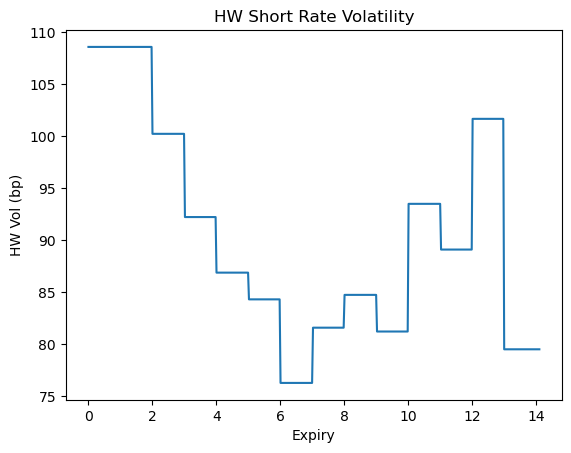

HW-1F Calibration Quality
------------------------------------------------------------------------------
Swaption        Market (bp)     HW-1F (bp)      Abs Err (bp)       Rel Err (%)
------------------------------------------------------------------------------
2Y x 13Y           559.1819       559.1819          0.000000          0.000000
3Y x 12Y           607.8102       607.8102          0.000000          0.000000
4Y x 11Y           619.2708       619.2708          0.000000          0.000000
5Y x 10Y           601.4789       601.4789          0.000000          0.000000
6Y x 9Y            566.7658       566.7658          0.000000          0.000000
7Y x 8Y            521.7944       521.7944          0.000000          0.000000
8Y x 7Y            472.0501       472.0501          0.000000          0.000000
9Y x 6Y            425.3753       425.3753          0.000000          0.000000
10Y x 5Y           374.9345       374.9345          0.000000          0.000000
11Y x 4Y           318.893

In [13]:
# IR yield curve asof 1st September 2023 (EURIBOR 6M)
zc_maturities = np.array([0.5, 1, 2, 5, 10, 15, 20, 30])
zc_rates = np.array([3.94, 3.91, 3.57, 3.12, 3.06, 3.09, 2.97, 2.65]) / 100
zc_curve = ZeroCouponRateCurve(zc_maturities, zc_rates)

# /!\ We calibrate the model using ATM instruments. 
# Best practice: using smile/skew-consistent vols at the Bermudan’s strike 3.35%, matching exactly the embedded European swaptions.
# ATM Normal Market Volatilities asof 1st September 2023 (EURIBOR 6M)
atm_normal_vols = np.array([98.43, 95.76, 92.75, 89.99, 87.68, 85.05, 83.62, 82.83, 81.87, 82.22, 82.11, 83.11, 82.24]) / 10000
atm_strikes = np.array([3.05, 3.06, 3.086, 3.12, 3.146, 3.165, 3.2, 3.21, 3.197, 3.203, 3.184, 3.181, 3.181]) / 100

# Calibration set of diagonal swaptions 2Y/13Y => 14Y/1Y
total_mat = 15
calib_set = []
i = 0
for expiry in range (2, total_mat) :
    tenor = total_mat - expiry
    swopt = EuropeanSwaption('payer', expiry, tenor, atm_strikes[i], fixed_frequency=0.5)
    swopt.set_market_data(zc_curve.df, atm_normal_vols[i])
    calib_set.append(swopt)
    i += 1

# Create and calibrate the HW-1F model
mean_reversion = 0.015
hw = HullWhiteOneFactorModel(mean_reversion)
hw.calibrate_sigma(calib_set)
print("HW-1F Calibrated Short Rate Vol : ")
hw.print()

# Print the calibration results
print("HW-1F Calibration Quality")
print("-" * 78)
print(f"{'Swaption':<12}{'Market (bp)':>15}{'HW-1F (bp)':>15}{'Abs Err (bp)':>18}{'Rel Err (%)':>18}")
print("-" * 78)
for swopt in calib_set:
    market_price = swopt.market_price()
    hw1f_price = hw.price(swopt)
    tenor = int(swopt.pay_times[-1] - swopt.start_time)
    abs_error_bp = abs(hw1f_price - market_price)
    rel_error_pct = 100. * abs(hw1f_price / market_price - 1.) if market_price != 0. else float('nan')

    print(f"{f'{swopt.expiry}Y x {tenor}Y':<12}"
          f"{market_price:>15.4f}"
          f"{hw1f_price:>15.4f}"
          f"{abs_error_bp:>18.6f}"
          f"{rel_error_pct:>18.6f}")

print("-" * 78)

The analytical Hull-White calibration reproduces the target calibration basket exactly. We then use PDE repricing of the same instruments as an implementation cross-check.

In [14]:
# PDE's params
nx = 501
nstdev = 5
dt = 0.001

# Reprice all swaptions in calibration set using the PDE method
print("PDE HW-1F Pricing Results")
print("-" * 78)
print(f"{'Swaption':<12}{'PDE (bp)':>15}{'Market (bp)':>15}{'Abs Err (bp)':>18}{'Rel Err (%)':>18}")
print("-" * 78)
for swaption in calib_set:
    pde = HullWhiteOneFactorPDEPricer(zc_curve.df, hw, nx, nstdev, dt, event_t=[swaption.expiry])
    def european_swaption_payoff(t, v_t, strike):
        if np.isclose(t, swaption.expiry):
            v_t = np.maximum(pde.pv_underlying(t, swaption, strike), 0.)
        return v_t
    pde_price = pde.compute_price(european_swaption_payoff, swaption.strike)
    market_price = swaption.market_price()
    tenor = int(swaption.pay_times[-1] - swaption.start_time)
    abs_error_bp = abs(pde_price - market_price)
    rel_error_pct = 100. * abs(pde_price / market_price - 1.) if market_price != 0. else float('nan')
    print(f"{f'{swaption.expiry}Y x {tenor}Y':<12}"
          f"{pde_price:>15.4f}"
          f"{market_price:>15.4f}"
          f"{abs_error_bp:>18.6f}"
          f"{rel_error_pct:>18.6f}")
print("-" * 78)

PDE HW-1F Pricing Results
------------------------------------------------------------------------------
Swaption           PDE (bp)    Market (bp)      Abs Err (bp)       Rel Err (%)
------------------------------------------------------------------------------
2Y x 13Y           559.1828       559.1819          0.000892          0.000160
3Y x 12Y           607.7862       607.8102          0.024017          0.003951
4Y x 11Y           619.2704       619.2708          0.000371          0.000060
5Y x 10Y           601.4696       601.4789          0.009298          0.001546
6Y x 9Y            566.7637       566.7658          0.002116          0.000373
7Y x 8Y            521.7949       521.7944          0.000535          0.000102
8Y x 7Y            472.0492       472.0501          0.000897          0.000190
9Y x 6Y            425.3777       425.3753          0.002386          0.000561
10Y x 5Y           374.9319       374.9345          0.002621          0.000699
11Y x 4Y           318.895

With the model calibrated and validated, we are now ready to price the $15$-year Bermudan swaption :

In [15]:
print("15Y Annually Bermudan Swaption, exercisable annually from year 2Y to year 14Y (in bp):")
print("--------------------------------------------------------------------------------------")
# Set event_t = calib_set expiries
event_t = []
for swaption in calib_set :
    event_t.append(swaption.expiry)
# Initialize the HW PDE pricer 
pde = HullWhiteOneFactorPDEPricer(zc_curve.df, hw, nx, nstdev, dt, event_t)
# PayOff function of bermudan swaption based upon the calib_set
def bermudan_swaption_payoff(t, v_t, strike):
    for swopt in calib_set:
        if (np.isclose(t, swopt.expiry)):
            v_t = np.maximum(pde.pv_underlying(t, swopt, strike), v_t)
            break
    return v_t
# Bermudan's strike
bermudan_strike = 3.35 / 100
# HW PDE price
bermudan_price = pde.compute_price(bermudan_swaption_payoff, bermudan_strike)
print("HW-1F Bermudan Swaption Price : {:.4f}".format(bermudan_price))

15Y Annually Bermudan Swaption, exercisable annually from year 2Y to year 14Y (in bp):
--------------------------------------------------------------------------------------
HW-1F Bermudan Swaption Price : 731.1474


So far, we have assumed a mean-reversion parameter of $1.5\%$. We now value the Bermudan swaption over a range of mean-reversion values from $0.5\%$ to $5\%$:

Bermudan Swaption Price Sensitivity to Mean Reversion
----------------------------------------------------
    Mean Reversion |  Bermudan Price (bp)
----------------------------------------------------
           0.5000% |             716.8742
           0.7500% |             720.4501
           1.0000% |             724.0107
           1.2500% |             727.5670
           1.5000% |             731.1474
           1.7500% |             734.7152
           2.0000% |             738.2920
           2.2500% |             741.8784
           2.5000% |             745.4260
           2.7500% |             749.0289
           3.0000% |             752.6186
           3.2500% |             756.1685
           3.5000% |             759.7818
           3.7500% |             763.3631
           4.0000% |             766.9244
           4.2500% |             770.5337
           4.5000% |             774.1077
           4.7500% |             777.6892
           5.0000% |             781.2837


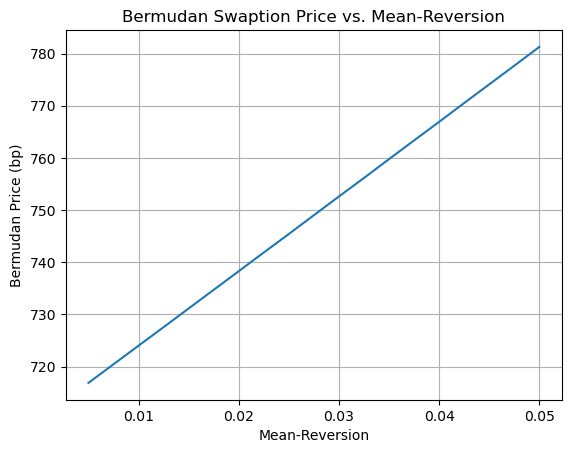

In [16]:
print("Bermudan Swaption Price Sensitivity to Mean Reversion")
print("-" * 52)
print(f"{'Mean Reversion':>18} | {'Bermudan Price (bp)':>20}")
print("-" * 52)
# Mean reversion values to test
mean_reversions = np.linspace(0.005, 0.05, 19)
# Bermudan price vs. mean-reversion
bermudan_prices = np.empty(len(mean_reversions))
for i in range(len(mean_reversions)) :
    # Rebuild and recalibrate the HW-1F model
    hw = HullWhiteOneFactorModel(mean_reversions[i])
    hw.calibrate_sigma(calib_set)
    # Initialize the HW PDE pricer
    pde = HullWhiteOneFactorPDEPricer(zc_curve.df, hw, nx, nstdev, dt, event_t)
    # HW PDE price
    bermudan_prices[i] = pde.compute_price(bermudan_swaption_payoff, bermudan_strike)
    print(f"{mean_reversions[i]:>18.4%} | {bermudan_prices[i]:>20.4f}")
print("-" * 52)
print("Minimum price : {:.4f} bp".format(np.min(bermudan_prices)))
print("Maximum price : {:.4f} bp".format(np.max(bermudan_prices)))
print("Price range   : {:.4f} bp".format(np.max(bermudan_prices) - np.min(bermudan_prices)))
print("-" * 52)

# Plot
plt.title("Bermudan Swaption Price vs. Mean-Reversion")
plt.xlabel("Mean-Reversion")
plt.ylabel("Bermudan Price (bp)")
bermudan_price_func = PchipInterpolator(mean_reversions, bermudan_prices, extrapolate=True)
x_axis = np.linspace(mean_reversions[0], mean_reversions[-1], 101)
plt.plot(x_axis, bermudan_price_func(x_axis))
plt.grid()
plt.show()